# Demand forecasting for the NYC yellow taxi

Objectives: 
1. To analyse the NYC yellow taxi data and build a ML model for forecasting taxi demand.
2. To demonstrate explainable AI (XAI) using feature importance calculations.
3. To derive business insights from the data.

## Loading the necessary packages

In [1]:
# Files and timestamp processing
import os
import requests

# Data processing
import pandas as pd
import numpy as np

# Data visualisation libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning model and relevant libraries
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit

# Feature importance relevant libraries
import operator # For sorting feature importance
import shap # For SHAP values and feature importance
from lime.lime_tabular import LimeTabularExplainer # For LIME feature importance

# For model serialisation
import joblib

## Functions to load the data to be used this notebook

In [2]:
def download_taxi_data(year, month):
    """Download Yellow Taxi data for a specific year and month"""
    url = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{year}-{month:02d}.parquet"
    
    # Create data directory if it doesn't exist
    os.makedirs("raw_data", exist_ok=True)
    
    # Local file path
    file_path = f"raw_data/yellow_tripdata_{year}-{month:02d}.parquet"
    
    # Download only if file doesn't exist
    if not os.path.exists(file_path):
        print(f"Downloading data for {year}-{month:02d}...")
        response = requests.get(url)
        if response.status_code == 200:
            with open(file_path, 'wb') as f:
                f.write(response.content)
            print(f"Download complete: {file_path}")
        else:
            print(f"Failed to download: {response.status_code}")
    else:
        print(f"File already exists: {file_path}")
    
    return file_path

def download_data_for_period(start_year, start_month, end_year, end_month):
    """Download Yellow Taxi data for a given range of months"""
    for year in range(start_year, end_year + 1):
        # Calculate the correct month range for the current year
        month_start = start_month if year == start_year else 1
        month_end = end_month if year == end_year else 12
        
        for month in range(month_start, month_end + 1):
            download_taxi_data(year, month)

In [3]:
download_data_for_period(2023, 1, 2024, 12)

File already exists: raw_data/yellow_tripdata_2023-01.parquet
File already exists: raw_data/yellow_tripdata_2023-02.parquet
File already exists: raw_data/yellow_tripdata_2023-03.parquet
File already exists: raw_data/yellow_tripdata_2023-04.parquet
File already exists: raw_data/yellow_tripdata_2023-05.parquet
File already exists: raw_data/yellow_tripdata_2023-06.parquet
File already exists: raw_data/yellow_tripdata_2023-07.parquet
File already exists: raw_data/yellow_tripdata_2023-08.parquet
File already exists: raw_data/yellow_tripdata_2023-09.parquet
File already exists: raw_data/yellow_tripdata_2023-10.parquet
File already exists: raw_data/yellow_tripdata_2023-11.parquet
File already exists: raw_data/yellow_tripdata_2023-12.parquet
File already exists: raw_data/yellow_tripdata_2024-01.parquet
File already exists: raw_data/yellow_tripdata_2024-02.parquet
File already exists: raw_data/yellow_tripdata_2024-03.parquet
File already exists: raw_data/yellow_tripdata_2024-04.parquet
File alr

## Exploratory data analysis (EDA)

In [4]:
# Getting a sample data to inspect the columns
sample_data = "raw_data/yellow_tripdata_2024-12.parquet"
sample_data_filepath = os.path.join(os.getcwd(), sample_data)
df_sample = pd.read_parquet(sample_data_filepath)
df_sample.head(1000)

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee
0,2,2024-12-01 00:12:27,2024-12-01 00:31:12,1.0,9.76,1.0,N,138,33,1,38.0,6.0,0.5,4.72,0.00,1.0,51.97,0.0,1.75
1,2,2024-11-30 23:56:04,2024-12-01 00:28:15,1.0,7.62,1.0,N,158,42,1,37.3,1.0,0.5,8.46,0.00,1.0,50.76,2.5,0.00
2,2,2024-12-01 00:50:35,2024-12-01 01:24:46,4.0,20.07,2.0,N,132,236,2,70.0,0.0,0.5,0.00,6.94,1.0,82.69,2.5,1.75
3,2,2024-12-01 00:18:16,2024-12-01 00:33:16,3.0,2.34,1.0,N,142,186,1,15.6,1.0,0.5,4.12,0.00,1.0,24.72,2.5,0.00
4,2,2024-12-01 00:56:13,2024-12-01 01:18:25,1.0,5.05,1.0,N,107,80,1,26.8,1.0,0.5,5.00,0.00,1.0,36.80,2.5,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,1,2024-12-01 00:05:48,2024-12-01 00:29:08,1.0,4.70,1.0,N,137,7,1,22.6,3.5,0.5,5.50,0.00,1.0,33.10,2.5,0.00
996,2,2024-12-01 00:26:14,2024-12-01 00:27:03,1.0,0.08,1.0,N,230,230,2,3.0,1.0,0.5,0.00,0.00,1.0,8.00,2.5,0.00
997,1,2024-12-01 00:25:33,2024-12-01 00:31:02,1.0,0.80,1.0,N,238,239,2,7.9,3.5,0.5,0.00,0.00,1.0,12.90,2.5,0.00
998,2,2024-12-01 00:19:04,2024-12-01 00:33:44,6.0,4.69,1.0,N,148,263,1,20.5,1.0,0.5,2.00,0.00,1.0,27.50,2.5,0.00


Aggregating data by the hour and limiting the number of features for efficiency:

In [5]:
def aggregate_and_combine(input_folder="raw_data"):
    """
    Aggregate each file by the hour and combine results into a single DataFrame.

    Parameters:
        input_folder (str): Path to the folder containing raw Parquet files.

    Returns:
        pd.DataFrame: Combined hourly-aggregated DataFrame from all files.
    """
    file_paths = [os.path.join(input_folder, file) for file in os.listdir(input_folder) if file.endswith(".parquet")]
    file_paths.sort()
    
    aggregated_dfs = []  # List to store hourly-aggregated DataFrames

    for file_path in file_paths:
        try:
            print(f"Processing {file_path}...")
            df = pd.read_parquet(file_path)
            
            # Handle datetime column inconsistencies
            if "pickup_datetime" in df.columns:
                df["pickup_hour"] = pd.to_datetime(df["pickup_datetime"]).dt.floor("h")
            elif "tpep_pickup_datetime" in df.columns:
                df["pickup_hour"] = pd.to_datetime(df["tpep_pickup_datetime"]).dt.floor("h")
            else:
                print(f"Skipping file {file_path} - no suitable datetime column found.")
                continue
            
            # Aggregate (the most relevant features) by pick-up hour
            hourly_agg = df.groupby("pickup_hour").agg({
                "trip_distance": "mean",        # Total distance travelled
                "fare_amount": "mean",          # Total base fare amount
                "total_amount": "mean",         # Total revenue including tips and extras
                "passenger_count": "mean",     # Average passenger count
            }).reset_index()

            # Calculate trip volume (number of trips per hour)
            hourly_agg["trip_volume"] = df.groupby("pickup_hour")["pickup_hour"].count().values

            aggregated_dfs.append(hourly_agg)
            print(f"Aggregated file added: {file_path}")
        
        except Exception as e:
            print(f"Error processing {file_path}: {e}")
    
    if not aggregated_dfs:  # Guard against empty list
        print("No valid files to aggregate.")
        return None

    # Combine all hourly-aggregated DataFrames
    combined_df = pd.concat(aggregated_dfs, ignore_index=True)
    print(f"Combined DataFrame shape: {combined_df.shape}")
    return combined_df

In [6]:
hourly_taxi_data = aggregate_and_combine()

Processing raw_data\yellow_tripdata_2023-01.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-01.parquet
Processing raw_data\yellow_tripdata_2023-02.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-02.parquet
Processing raw_data\yellow_tripdata_2023-03.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-03.parquet
Processing raw_data\yellow_tripdata_2023-04.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-04.parquet
Processing raw_data\yellow_tripdata_2023-05.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-05.parquet
Processing raw_data\yellow_tripdata_2023-06.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-06.parquet
Processing raw_data\yellow_tripdata_2023-07.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-07.parquet
Processing raw_data\yellow_tripdata_2023-08.parquet...
Aggregated file added: raw_data\yellow_tripdata_2023-08.parquet
Processing raw_data\yellow_tripdata_2023-09.parq

Further EDA to find out what columns are there and if the data has missing values (which informs us for data cleaning)

In [7]:
print("Data Shape:", hourly_taxi_data.shape)
print("\nFirst Few Rows:")
print(hourly_taxi_data.head())
print("\nColumns and Data Types:")
print(hourly_taxi_data.dtypes)
print("\nSummary Statistics:")
print(hourly_taxi_data.describe())
print("\nMissing Values:")
print(hourly_taxi_data.isnull().sum())

Data Shape: (22266, 6)

First Few Rows:
          pickup_hour  trip_distance  fare_amount  total_amount  \
0 2008-12-31 23:00:00           8.88         35.0        40.275   
1 2022-10-24 17:00:00           0.00        120.0       120.300   
2 2022-10-24 20:00:00           0.00         45.0        54.360   
3 2022-10-24 21:00:00           0.00         75.0        90.360   
4 2022-10-24 23:00:00           0.00         55.0        72.250   

   passenger_count  trip_volume  
0              1.0            2  
1              1.0            1  
2              1.0            1  
3              1.0            1  
4              1.0            1  

Columns and Data Types:
pickup_hour        datetime64[us]
trip_distance             float64
fare_amount               float64
total_amount              float64
passenger_count           float64
trip_volume                 int64
dtype: object

Summary Statistics:
                      pickup_hour  trip_distance   fare_amount  total_amount  \
count    

In [8]:
hourly_taxi_data.head(2000)

,pickup_hour,trip_distance,fare_amount,total_amount,passenger_count,trip_volume
0,2008-12-31 23:00:00,8.880000,35.000000,40.275000,1.000000,2
1,2022-10-24 17:00:00,0.000000,120.000000,120.300000,1.000000,1
2,2022-10-24 20:00:00,0.000000,45.000000,54.360000,1.000000,1
3,2022-10-24 21:00:00,0.000000,75.000000,90.360000,1.000000,1
4,2022-10-24 23:00:00,0.000000,55.000000,72.250000,1.000000,1
...,...,...,...,...,...,...
1995,2023-03-22 09:00:00,2.841529,17.900371,25.817799,1.236360,5312
1996,2023-03-22 10:00:00,3.047700,18.730578,26.804234,1.274525,5262
1997,2023-03-22 11:00:00,2.925339,18.563542,26.520071,1.294106,5370
1998,2023-03-22 12:00:00,3.053616,18.988364,27.129887,1.281115,5672


## Data cleaning

Cleaning the data from outliers.

In [9]:
def clean_hourly_taxi_data(df):
    """Data cleaning and removing outliers"""
    df = df.copy()

    # 1. Ensure pickup_hour is datetime
    df['pickup_hour'] = pd.to_datetime(df['pickup_hour'])

    # 2. Filter between Jan 2023 and Dec 2024
    start_date = "2023-01-01"
    end_date = "2024-12-31"
    df = df[(df['pickup_hour'] >= start_date) & (df['pickup_hour'] <= end_date)]

    # 3. Remove invalid or extreme trip_distance
    df = df[df['trip_distance'] > 0]
    df = df[df['trip_distance'] < df['trip_distance'].quantile(0.999)]

    # 4. Remove invalid or extreme fare_amount
    df = df[df['fare_amount'] > 0]
    df = df[df['fare_amount'] < df['fare_amount'].quantile(0.999)]

    # 5. Round the passenger count to the nearest integer 
    # Replace NaN values in 'passenger_count' with the median directly
    df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

    # Replace infinite values if needed
    df["passenger_count"] = df["passenger_count"].replace([float("inf"), -float("inf")], df["passenger_count"].median())

    # Round passenger count and cast to integer
    df["passenger_count"] = df["passenger_count"].round().astype("int")

    # 5. Optional: Reset index
    df.reset_index(drop=True, inplace=True)

    return df

In [10]:
# Verifying that the data is cleaned and outliers are removed.
cleaned_hourly_taxi_data_df = clean_hourly_taxi_data(hourly_taxi_data)
print(cleaned_hourly_taxi_data_df.describe())

                      pickup_hour  trip_distance   fare_amount  total_amount  \
count                       17732   17732.000000  17732.000000  17732.000000   
mean   2023-12-31 08:38:52.325739       5.330784     20.249067     28.967523   
min           2023-01-01 00:00:00       0.005000      5.100000     10.500000   
25%           2023-06-30 18:45:00       3.155210     18.122265     26.383170   
50%           2023-12-30 19:30:00       3.560230     19.474100     28.091243   
75%           2024-07-01 20:15:00       4.608868     21.351039     30.409127   
max           2024-12-31 00:00:00     232.442128     51.300000     78.560000   
std                           NaN       9.804074      3.470157      4.266235   

       passenger_count   trip_volume  
count     17732.000000  17732.000000  
mean          1.053745   4475.588879  
min           0.000000      1.000000  
25%           1.000000   1865.750000  
50%           1.000000   5078.000000  
75%           1.000000   6447.000000  
max   

In [11]:
cleaned_hourly_taxi_data_df.head(10)

,pickup_hour,trip_distance,fare_amount,total_amount,passenger_count,trip_volume
0,2023-01-01 00:00:00,3.346406,18.688559,27.058283,2,5336
1,2023-01-01 01:00:00,3.251021,18.624696,27.017533,2,5752
2,2023-01-01 02:00:00,3.359829,18.329519,26.600518,2,5097
3,2023-01-01 03:00:00,3.502037,18.722401,26.826915,1,3952
4,2023-01-01 04:00:00,3.837981,19.660764,27.858461,1,2501
5,2023-01-01 05:00:00,4.930583,23.968049,32.444658,1,1097
6,2023-01-01 06:00:00,6.191487,27.887930,36.857996,1,908
7,2023-01-01 07:00:00,6.258012,27.161792,35.943242,1,1021
8,2023-01-01 08:00:00,5.862084,26.468474,35.544237,1,1147
9,2023-01-01 09:00:00,4.515509,21.488521,29.641624,1,1650


Exporting the cleaned dataset to .csv for documentation:

In [12]:
cleaned_hourly_taxi_data_df.to_csv("cleaned_hourly_taxi_data.csv", index=False)
print("Cleaned data saved to 'cleaned_hourly_taxi_data.csv'.")

Cleaned data saved to 'cleaned_hourly_taxi_data.csv'.


## Feature engineering

Here, I will extract the time units (e.g. year, month, day, day of the week, is_weekend) from the timestamp.

In [13]:
def add_time_features(df, time_column="pickup_hour"):
    """
    Add time-based features to a DataFrame.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        time_column (str): Name of the datetime column (default: "pickup_hour").
    
    Returns:
        pd.DataFrame: DataFrame with additional time-based features.
    """
    # Ensure the time_column is in datetime format
    df[time_column] = pd.to_datetime(df[time_column])
    
    # Extract time-based features
    df["year"] = df[time_column].dt.year
    df["month"] = df[time_column].dt.month
    df["day"] = df[time_column].dt.day
    df["hour"] = df[time_column].dt.hour
    df["dayofweek"] = df[time_column].dt.dayofweek  # 0=Monday, 6=Sunday
    
    # Add a weekend flag (1 if weekend, 0 otherwise)
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    
    return df


In [14]:
df_with_added_time_features = add_time_features(cleaned_hourly_taxi_data_df, "pickup_hour")

In [15]:
def correlate_and_visualise(df, target_column="trip_volume", exclude_columns=None):
    """
    Calculate correlations with the target column and visualise them as a heatmap.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        target_column (str): Name of the column to correlate with (default: "trip_volume").
        exclude_columns (list): List of columns to exclude from correlation (default: None).
    
    Returns:
        pd.Series: Correlation values sorted by magnitude.
    """
    # Drop excluded columns if provided
    if exclude_columns:
        df = df.drop(columns=exclude_columns)
    
    # Compute correlation matrix
    correlations = df.corr()[target_column].drop(target_column).sort_values(ascending=False)
    
    # Plot the heatmap for correlations
    plt.figure(figsize=(8, 6))
    sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Matrix")
    plt.show()
    
    return correlations


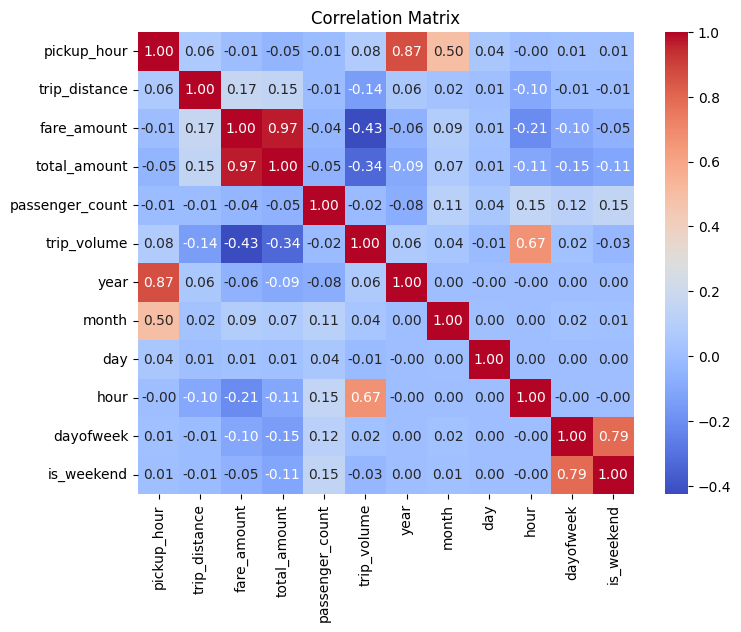

In [16]:
corr = correlate_and_visualise(df_with_added_time_features)

In [17]:
# Removing multicorrelated features, i.e., total_amount and fare_amount
#df_with_added_time_features = df_with_added_time_features.drop(columns=["total_amount", "fare_amount"])

## Data visualisation for seasonality

Analyses and plots to visualise the seasonal features in the NYC yellow taxi data.

In [18]:
def visualise_time_features(df, time_column="pickup_hour", target_column="trip_volume"):
    """
    Visualise time-based features to detect seasonalities in demand.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        time_column (str): Name of the datetime column (default: "pickup_hour").
        target_column (str): Name of the column to analyze (default: "trip_volume").
    
    Returns:
        None: Displays multiple plots for time-based features.
    """
    # Hourly patterns
    hourly_avg = df.groupby(df[time_column].dt.hour)[target_column].mean()
    plt.figure(figsize=(10, 6))
    hourly_avg.plot(kind="bar", color="skyblue")
    plt.title("Average Trip Volume by Hour of Day")
    plt.xlabel("Hour")
    plt.ylabel("Average Trip Volume")
    plt.show()
    
    # Weekly patterns
    weekly_avg = df.groupby(df[time_column].dt.dayofweek)[target_column].mean()
    plt.figure(figsize=(10, 6))
    weekly_avg.plot(kind="bar", color="orange")
    plt.title("Average Trip Volume by Day of Week")
    plt.xlabel("Day of Week (0=Monday, 6=Sunday)")
    plt.ylabel("Average Trip Volume")
    plt.xticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=45)
    plt.show()
    
    # Monthly patterns
    monthly_avg = df.groupby(df[time_column].dt.month)[target_column].mean()
    plt.figure(figsize=(10, 6))
    monthly_avg.plot(kind="bar", color="green")
    plt.title("Average Trip Volume by Month")
    plt.xlabel("Month")
    plt.ylabel("Average Trip Volume")
    plt.xticks(range(0, 12), ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"], rotation=45)
    plt.show()
    
    # Heatmap for day-of-week vs hour
    seasonality_pivot = df.pivot_table(index=df[time_column].dt.dayofweek,
                                       columns=df[time_column].dt.hour,
                                       values=target_column,
                                       aggfunc="mean")
    plt.figure(figsize=(12, 8))
    #sns.heatmap(seasonality_pivot, cmap="coolwarm", annot=True, fmt=".0f")
    sns.heatmap(seasonality_pivot, cmap="coolwarm", annot=False)
    plt.title("Average Trip Volume by Day of Week and Hour")
    plt.xlabel("Hour")
    plt.ylabel("Day of Week")
    plt.xticks(range(24), range(24), rotation=90)
    plt.yticks(range(7), ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"], rotation=0)
    plt.show()


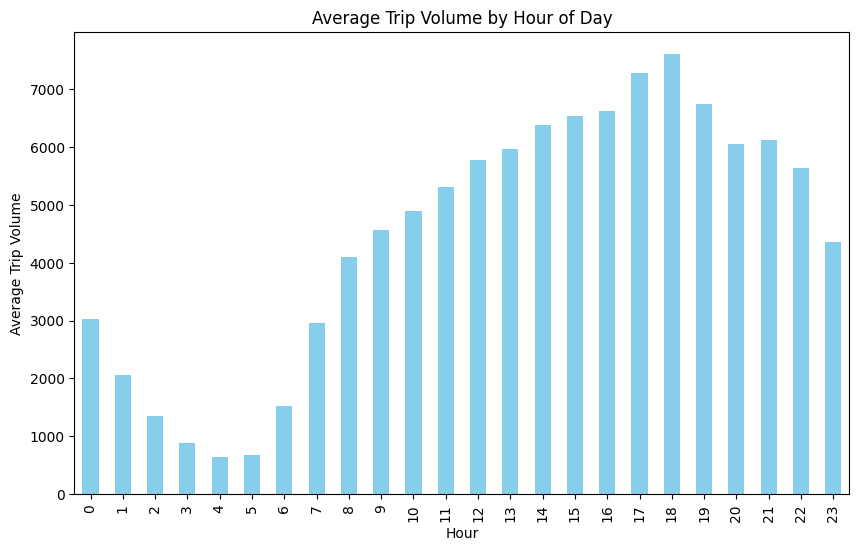

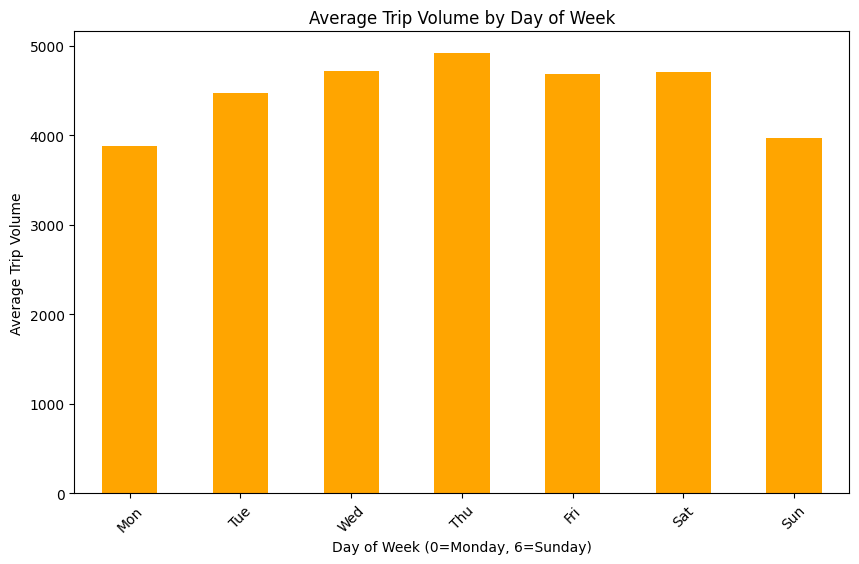

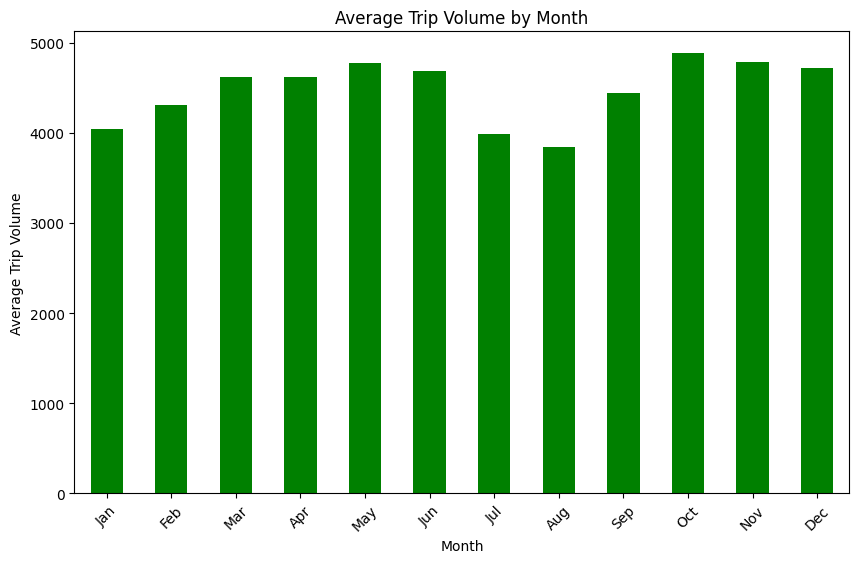

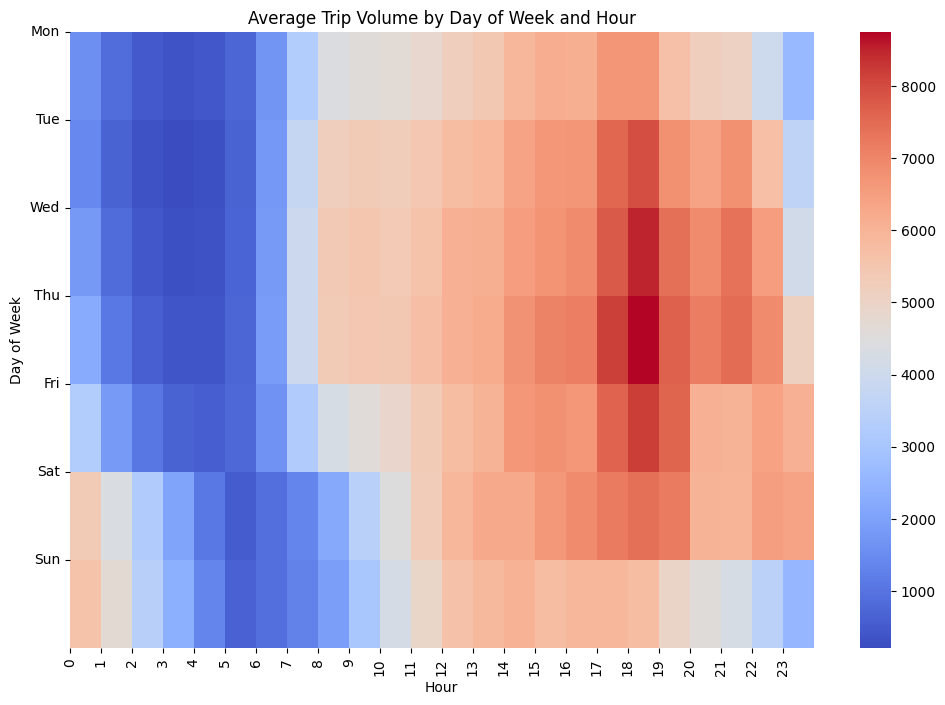

In [19]:
visualise_time_features(df_with_added_time_features, time_column="pickup_hour", target_column="trip_volume")

In [20]:
def plot_yearly_seasonality(df, date_column='pickup_hour', target_column='trip_volume'):
    """
    Plots the yearly seasonality by comparing trip volumes for 2023 and 2024.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        date_column (str): Name of the date column (default: 'pickup_hour').
        target_column (str): Name of the target column (default: 'trip_volume').
    """

    df[date_column] = pd.to_datetime(df[date_column])  # Ensure datetime format

    # Filter data for 2023 and 2024
    df_2023 = df[df[date_column].dt.year == 2023]
    df_2024 = df[df[date_column].dt.year == 2024]

    # Group by day and sum trip volumes
    daily_2023 = df_2023.resample('D', on=date_column)[target_column].sum()
    daily_2024 = df_2024.resample('D', on=date_column)[target_column].sum()

    # Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(daily_2023.index, daily_2023.values, label='2023', alpha=0.7)
    plt.plot(daily_2024.index, daily_2024.values, label='2024', alpha=0.7)

    plt.xlabel('Date')
    plt.ylabel('Total Trip Volume')
    plt.title('Yearly Seasonality: Trip Volumes in 2023 vs. 2024')
    plt.legend()
    plt.grid(True)
    plt.show()

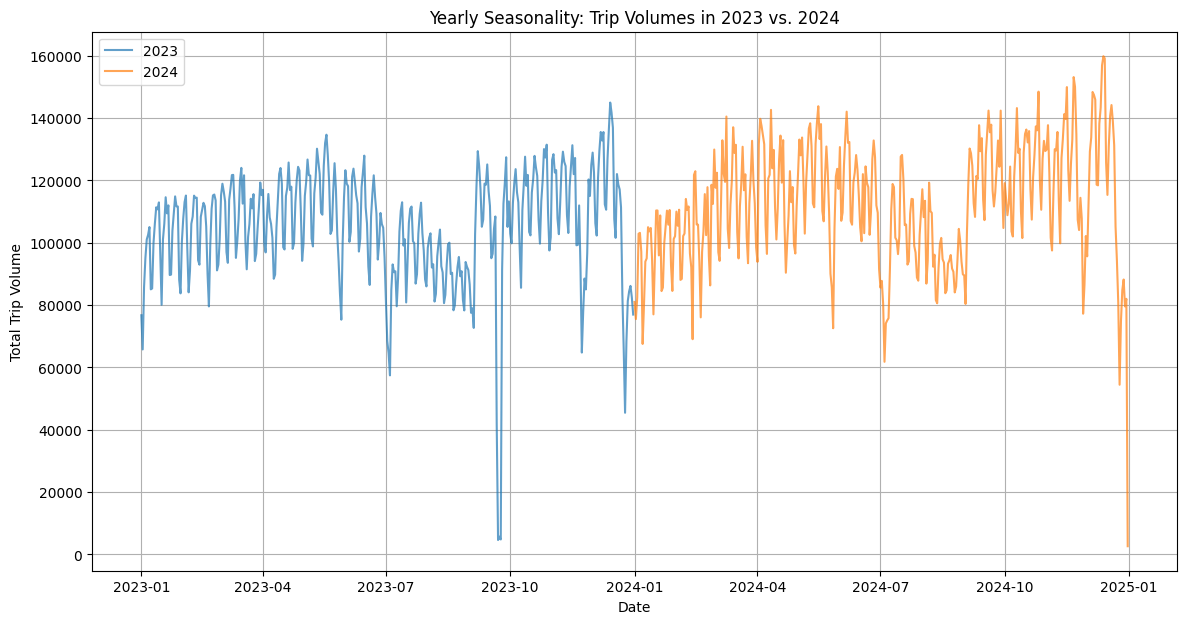

In [21]:
plot_yearly_seasonality(df_with_added_time_features)

In [22]:
def add_lag_features(df, target_column="trip_volume", lags=[24, 168, 8760]): # original  lags=[1, 24, 168]
    """
    Add lagged features to capture temporal dependencies in demand.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        target_column (str): Name of the column to lag (default: "trip_volume").
        lags (list): List of lag periods (default: [1, 24, 168]).
    
    Returns:
        pd.DataFrame: DataFrame with added lag features.
    """
    for lag in lags:
        df[f"lag_{lag}"] = df[target_column].shift(lag)

    for col in df.columns:
        if col.startswith("lag_"):
            df[col] = df[col].fillna(df[col].median()) # Fill with median

    return df

Overall, the NYC taxi data shows strong seasonalities (daily, weekly, yearly) - hence the choices for the lag features.

## Demand forecasting with XGBoost

As the data is multi-seasonal and multivariate, I will use the XGBoost model for forecasting.

### Setting up the dataframes for XGBoost modelling

I will compare 4 cases: baseline model, baseline with interaction terms, baseline with lag terms, and baseline with both interaction and lag terms.

In [23]:
# Baseline df
df_baseline = df_with_added_time_features.copy() 

# Baseline + interaction terms
df_interaction = df_baseline.copy() 
df_interaction["day_hour_interaction"] = df_interaction["dayofweek"] * df_interaction["hour"]
df_interaction["day_passenger_count_interaction"] = df_interaction["dayofweek"] * df_interaction["passenger_count"]
df_interaction["day_trip_distance_interaction"] = df_interaction["dayofweek"] * df_interaction["trip_distance"]

# Baseline + lag features
df_lag = add_lag_features(df_baseline.copy() , target_column="trip_volume", lags=[24, 168, 8760])

# Baseline + interaction terms + lag features
df_interaction_lag = add_lag_features(df_interaction.copy() , target_column="trip_volume", lags=[24, 168, 8760]) 

# Put the dataframes into a list for easier processing
df_list = [df_baseline, df_interaction, df_lag, df_interaction_lag]

### Setting up XGBoost model

For the XGBoost model, I will use the TimeSeriesSplit for splitting the data. I am also keeping the hyperparameter fixed (i.e., n_estimators = 1000) for efficiency. 

In [24]:
def train_xgboost(df, target_column='trip_volume', date_column='pickup_hour', features=None):

    # sort values before choosing X and y
    df = df.sort_values(by='pickup_hour')

    #  default features if not provided
    if features is None:
        features = [col for col in df.columns if col not in [target_column, date_column]]

    # Prepare predictors (X) and target (y)
    X = df[features]
    y = df[target_column]
  
    tscv = TimeSeriesSplit(n_splits=5) # Split time series data, respecting the time order
    rmses = []
    maes = []
    r2s = []

    for train_index, test_index in tscv.split(X, y): # added y
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model = xgb.XGBRegressor(
                    n_estimators=5000, # Set a very large number of trees
                    learning_rate=0.05, # A common learning rate
                    objective='reg:squarederror', # Or 'reg:linear' for older versions
                    eval_metric='rmse', # Metric to monitor for early stopping
                    random_state=42,
                    n_jobs=-1 # Use all available cores
                )

        # Define the validation set for early stopping
        eval_set = [(X_train, y_train), (X_test, y_test)]

        # Fit the model with early stopping
        model.fit(X_train, y_train,
                eval_set=eval_set,
                verbose=False # Set to True to see progress during training
                )

        #model = xgb.XGBRegressor(objective='reg:squarederror', eval_metric='rmse', n_estimators=1000, random_state=42)
        #model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)

        y_pred = model.predict(X_test)
        rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
        maes.append(mean_absolute_error(y_test, y_pred))
        r2s.append(r2_score(y_test, y_pred))

    rmse = np.mean(rmses)
    mse = rmse**2
    mae = np.mean(maes)
    r2 = np.mean(r2s)

    return model, mae, mse, rmse, r2

In [25]:
def train_xg_boost_multiple_dfs(df_list):
    metrics = []
    model_array = []
    metrics_df = []
    for i, df in enumerate(df_list):
        # Define the feature set name based on the DataFrame
        feature_set_name = ['Baseline', 'Interaction Terms', 'Lag Features', 'Both'][i]
        
        # Train the XGBoost model and get metrics
        model, mae, mse, rmse, r2 = train_xgboost(df, target_column='trip_volume', date_column='pickup_hour', features=None)
        
        # Store the metrics for comparison
        metrics.append({
            'feature_set': feature_set_name,
            'mae': mae,
            'mse': mse,
            'rmse': rmse,
            'r2': r2
        })

        model_array.append(model)

    metrics_df = pd.DataFrame(metrics)

    return model_array, metrics_df 

### Identifying the best performing model

The best performing model, in this case (for forecasting task, which is a regression task), is the one with the lowest root mean square error (RMSE).

In [26]:
model_array, metrics_df = train_xg_boost_multiple_dfs(df_list)
print(metrics_df)

         feature_set         mae            mse        rmse        r2
0           Baseline  616.708563  854051.520532  924.149079  0.874430
1  Interaction Terms  620.363477  886815.929332  941.709047  0.867612
2       Lag Features  515.492908  618507.128904  786.452242  0.910416
3               Both  522.749005  636075.616539  797.543489  0.907799


In [27]:
# Step 1: Find the index of the best performing metrics (lowest RMSE)
best_index = metrics_df['rmse'].idxmin()
# Step 2: Select the corresponding model from model_array
best_model = model_array[best_index]
# Step 3: Select the corresponding model from model_array
best_df = df_list[best_index]

## Feature importance based on the best performing model

This is to demonstrate industry-standard explainable AI (XAI) and allow us to identify which features have the biggest contributions to our machine learning model.

### 1. Model specific feature importance - use XGBoost's native feature importance:

hour: 25611090.0000
lag_24: 7233928.5000
passenger_count: 2991761.5000
dayofweek: 2347210.2500
lag_168: 2171694.0000
fare_amount: 1433834.5000
trip_distance: 1091066.3750
month: 445963.2812
day: 422159.3125
total_amount: 405700.8750
lag_8760: 222365.9688
year: 207619.8125


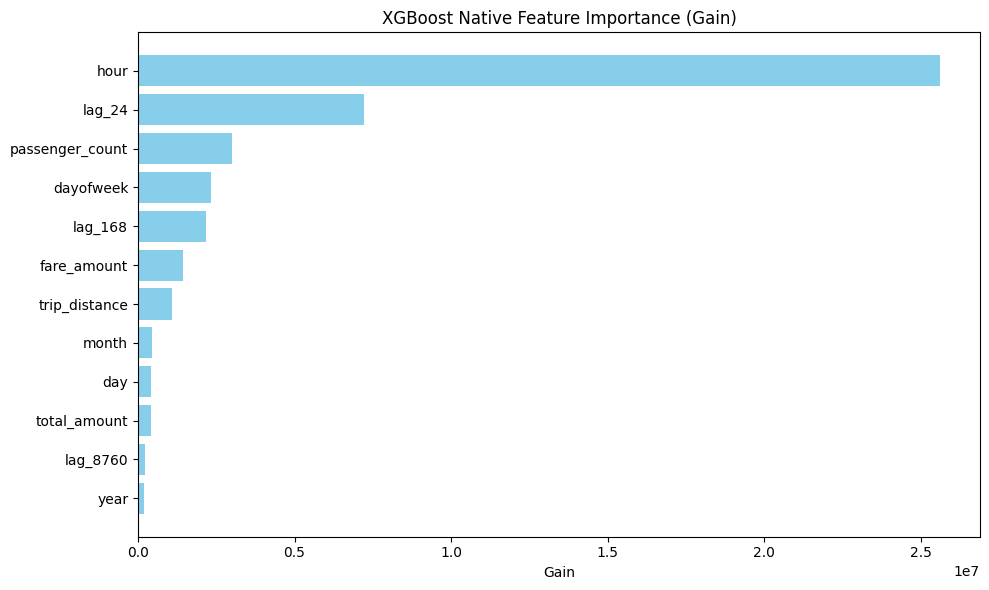

In [28]:
# Get and sort the feature importances
importances = best_model.get_booster().get_score(importance_type='gain')
sorted_importances = dict(sorted(importances.items(), key=operator.itemgetter(1), reverse=True))

# Print sorted importances
for feature, importance in sorted_importances.items():
    print(f"{feature}: {importance:.4f}")

# Plot horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(list(sorted_importances.keys())[::-1], list(sorted_importances.values())[::-1], color='skyblue')
plt.xlabel("Gain")
plt.title("XGBoost Native Feature Importance (Gain)")
plt.tight_layout()
plt.show()

The above feature importance plot (for XGBoost's native feature importance) shows are hour, lag_24, passenger count, day of week, and lag_168 to be the most important features.

### 2. Model agnostic feature importance - using SHAP and LIME:

#### SHAP feature importance

In [29]:
# Loading the SHAP Explainer
explainer = shap.Explainer(best_model)

Identifying the correct dataframe for SHAP

In [30]:
# Extracting the dataframe, columns, and features for SHAP values
df_shap = df_lag.sort_values(by='pickup_hour')

# Identifying the target and date columns
target_column='trip_volume' 
date_column='pickup_hour'

#  default features if not provided
features=None
if features is None:
    features = [col for col in df_shap.columns if col not in [target_column, date_column]]

# Prepare predictors (X) and target (y)
X = df_shap[features]
y = df_shap[target_column]

Splitting the dataset into train and test:

In [31]:
# Splitting the data for SHAP calculations
split_index = int(0.8 * len(X))  # 80-20 split

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# Ensuring that the columns in X_test match those in X_train
assert list(X_test.columns) == list(X_train.columns)

Calculating the SHAP values

In [32]:
# Sample 100 rows for SHAP values
X_sample = X_test.sample(n=100, random_state=42) 
explainer = shap.Explainer(best_model, X_train)
shap_values = explainer(X_sample, check_additivity=False)  # Set check_additivity=False to avoid warnings

 99%|===================| 99/100 [00:31<00:00]        

            feature   importance
7              hour  1056.354014
10           lag_24   678.857005
1       fare_amount   362.410278
0     trip_distance   293.820826
8         dayofweek   176.587180
6               day   172.939541
5             month   147.065431
2      total_amount   102.414083
11          lag_168    99.801530
12         lag_8760    49.447125
4              year    34.934292
3   passenger_count    34.501568
9        is_weekend     0.000000


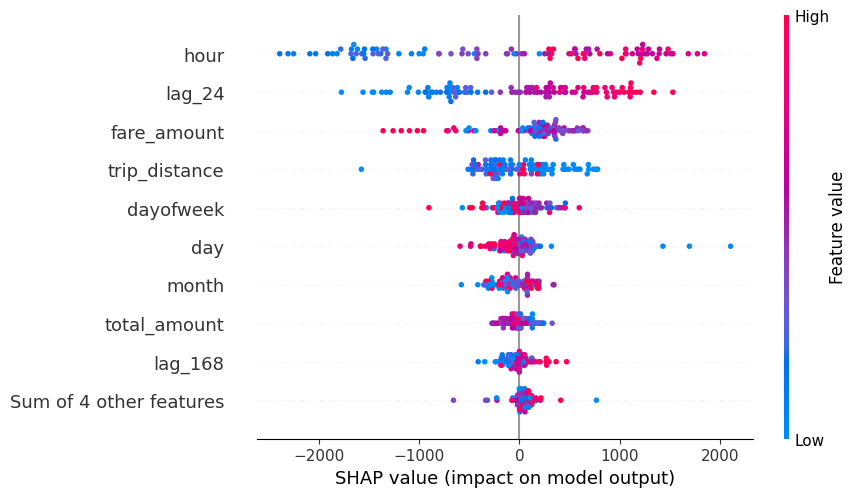

In [33]:
# Calculate mean absolute SHAP value for each feature
importance_df = pd.DataFrame({
    "feature": X_sample.columns,
    "importance": np.abs(shap_values.values).mean(axis=0)
})

# Sort descending by importance
importance_df = importance_df.sort_values(by="importance", ascending=False)

# Show top features
print(importance_df)

# Plotting the SHAP values
shap.plots.beeswarm(shap_values)  # Set check_additivity=False to avoid warnings

The most important features identified by SHAP are: hour, lag_24, fare amount, trip distance, day of the week.

LIME Feature Importance

In [34]:
# Loading the LimeTabularExplainer
explainer = LimeTabularExplainer(
    training_data=X_train.values,
    feature_names=X_train.columns,
    mode='regression'
)

i = 0  # index of instance to explain
exp = explainer.explain_instance(
    data_row=X_test.iloc[i].values,
    predict_fn=best_model.predict
)

Converting the LIME feature importance into a list and then a Pandas dataframe:

In [35]:
# Converting LIME explanation to a DataFrame
lime_tuples = exp.as_list()
lime_df = pd.DataFrame(lime_tuples, columns=['Feature', 'Importance'])

Plotting the LIME feature importance

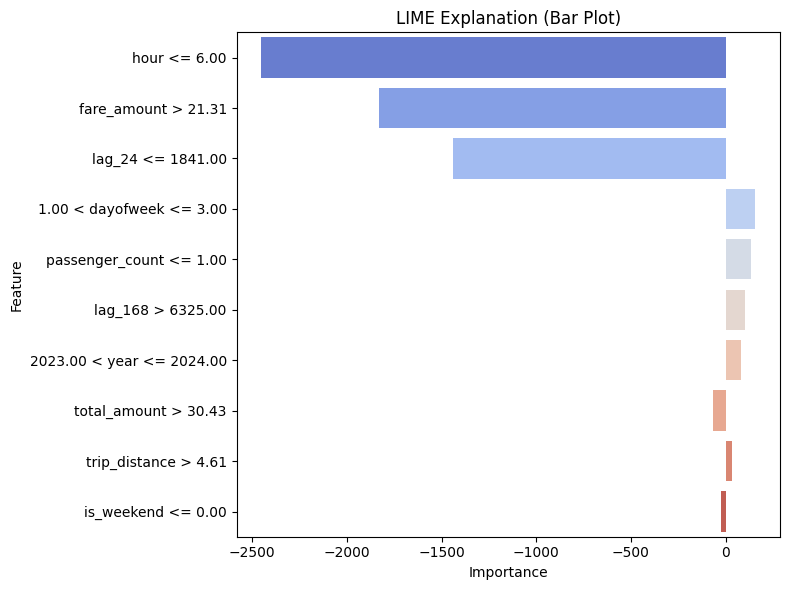

In [36]:
# Sorting the LIME DataFrame by importance
lime_df.sort_values('Importance', ascending=False)

# Plotting the LIME explanation
plt.figure(figsize=(8, 6))
sns.barplot(data=lime_df, y='Feature', x='Importance', hue='Feature', palette='coolwarm', legend=False)
plt.title('LIME Explanation (Bar Plot)')
plt.tight_layout()
plt.show()

The most important features identified by SHAP are: hour, fare_amount, lag_24, day of week, passenger count.

#### A short commentary on the feature importance

1. Across XGBoost and SHAP, hour consistently emerged as the most important feature, indicating strong model alignment. 
2. Other key features such as lag_24, day of the week, fare amount, and passenger count also appeared across all methods, though with slight variation in ranking - showing that the strong temporal dependence of the data. 
3. This consistency suggests that the XGBoost model is learning stable and interpretable patterns in the data.

## Serialising best model

We need to serialise the best model for inference.

In [37]:
# Serialising the best model
best_model, mae, mse, rmse, r2 = train_xgboost(best_df)
joblib.dump(best_model, 'best_model_reloaded.joblib')

['best_model_reloaded.joblib']

In [ ]:
best_df.head(5)

,pickup_hour,trip_distance,fare_amount,total_amount,passenger_count,trip_volume,year,month,day,hour,dayofweek,is_weekend,lag_24,lag_168,lag_8760
0,2023-01-01 00:00:00,3.346406,18.688559,27.058283,2,5336,2023,1,1,0,6,1,5078.0,5090.5,4937.0
1,2023-01-01 01:00:00,3.251021,18.624696,27.017533,2,5752,2023,1,1,1,6,1,5078.0,5090.5,4937.0
2,2023-01-01 02:00:00,3.359829,18.329519,26.600518,2,5097,2023,1,1,2,6,1,5078.0,5090.5,4937.0
3,2023-01-01 03:00:00,3.502037,18.722401,26.826915,1,3952,2023,1,1,3,6,1,5078.0,5090.5,4937.0
4,2023-01-01 04:00:00,3.837981,19.660764,27.858461,1,2501,2023,1,1,4,6,1,5078.0,5090.5,4937.0


In [39]:
# Saving the best model's corresponding dataframe for lag feature calculations in predict.py
best_df.to_csv('best_df.csv', index=False)

## Business insights and conclusions

Based on the above analysis, multiple insights and conclusions can be made.

1. The NYC yellow taxi data reveals clear seasonal patterns at daily, monthly, and yearly scales.

2. Understanding these patterns allows businesses to allocate resources more efficiently and refine pricing or marketing strategies in response to predictable demand fluctuations.

3. Through explainable AI (XAI) techniques—including SHAP, LIME, and XGBoost’s built-in feature importance—we identified key drivers of demand such as trip distance, time of day, and temporal lag features, enhancing both model transparency and business interpretability.

4. Incorporating seasonality via lag features significantly improved forecasting performance—reducing RMSE by approximately 10% compared to a baseline model—demonstrating the value of temporal awareness in predictive modeling.

5. Ultimately, data science and MLOps are tools to drive better business outcomes—their value lies in how effectively they inform and enable decision-making, not in their technical sophistication alone.